In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.ensemble import RandomForestClassifier

In [48]:
df = pd.read_csv("/kaggle/input/datasets/atharvaingle/crop-recommendation-dataset/Crop_recommendation.csv")

print(df.head())
print(df.info())
print(df.describe())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
         

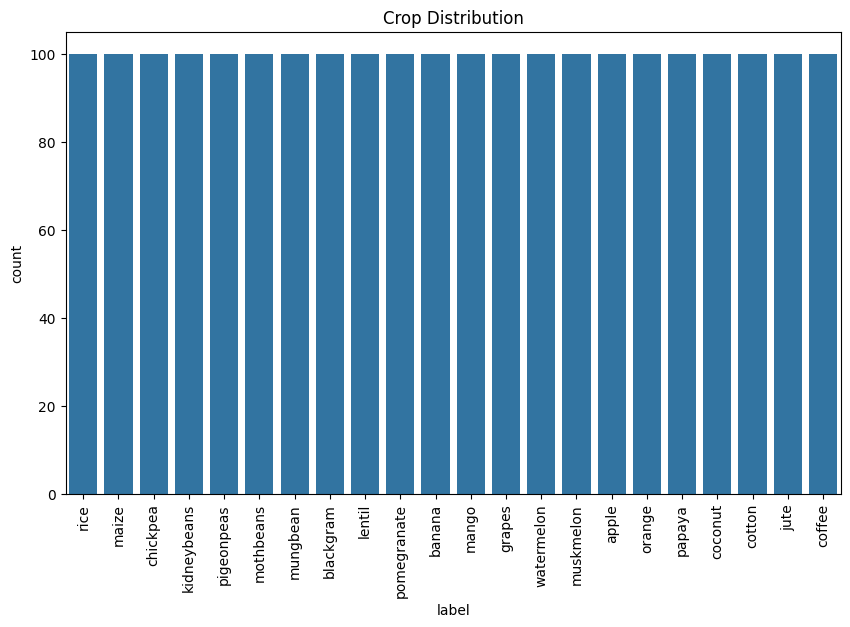

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='label')
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

In [50]:
X = df.drop('label', axis=1)
y = df['label']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
# 📌 Scaling (IMPORTANT)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split# 📌 Model
model = LogisticRegression(max_iter=200, multi_class='multinomial')

# 📌 Train
model.fit(X_train, y_train)

# 📌 Predict

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=200, multi_class='multinomial')

In [63]:
# 📌 Predict
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 📌 Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)

# 📌 Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.977840909090909
Test Accuracy : 0.9636363636363636

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.

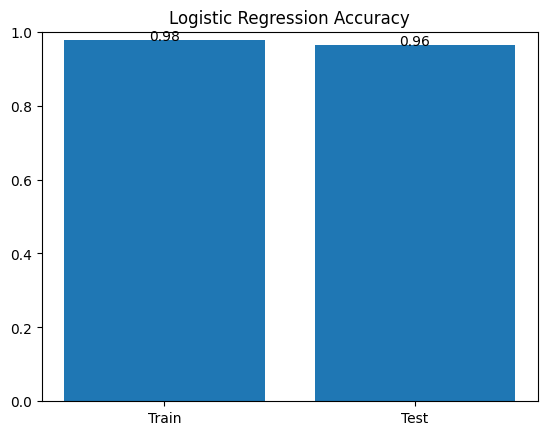

In [66]:
import matplotlib.pyplot as plt

plt.bar(['Train', 'Test'], [train_acc, test_acc])
plt.title("Logistic Regression Accuracy")
plt.ylim(0,1)

for i, v in enumerate([train_acc, test_acc]):
    plt.text(i, v, round(v,2), ha='center')

plt.show()

In [67]:
# Example input
new_data = [[90, 40, 40, 25, 80, 6.5, 200]]

# Scale
new_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_scaled)

print("Recommended Crop:", prediction[0])

Recommended Crop: mothbeans


In [69]:
model = LogisticRegression(
    max_iter=500,
    C=1,
    solver='lbfgs',
    multi_class='multinomial'
)

In [75]:
# 1. Train model (MUST)
model.fit(X_train, y_train)

# 2. New input
new_data = [[70, 45, 45, 23, 55, 6.0, 120]]

# 3. Convert to DataFrame (fix warning)
import pandas as pd
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# 4. Scale
new_scaled = scaler.transform(new_data_df)

# 5. Predict
prediction = model.predict(new_scaled)

print("Recommended Crop:", prediction[0])

Recommended Crop: maize


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


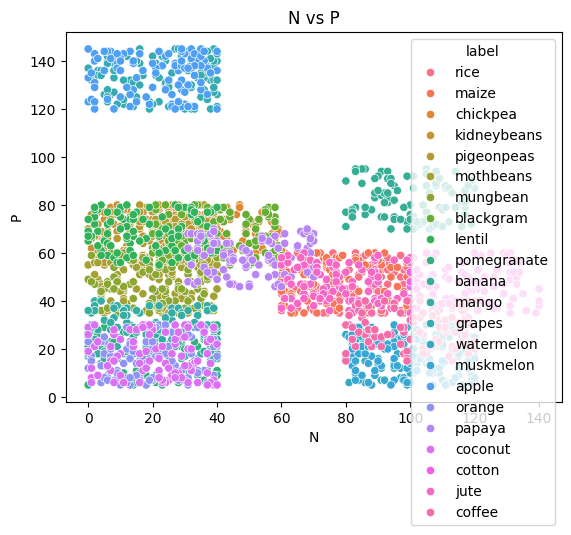

In [76]:
plt.figure()

sns.scatterplot(data=df, x='N', y='P', hue='label')

plt.title("N vs P")
plt.show()

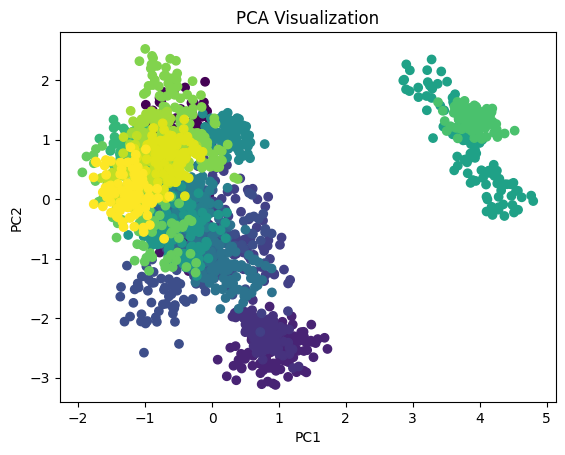

In [77]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()

plt.scatter(X_pca[:,0], X_pca[:,1], c=pd.factorize(y)[0])

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

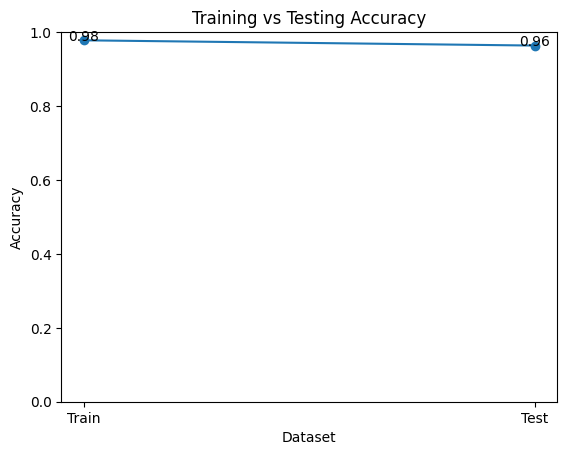

In [79]:
import matplotlib.pyplot as plt

# Accuracy values
labels = ['Train', 'Test']
values = [train_acc, test_acc]

# Plot line graph
plt.figure()

plt.plot(labels, values, marker='o')

plt.title("Training vs Testing Accuracy")
plt.xlabel("Dataset")
plt.ylabel("Accuracy")
plt.ylim(0,1)

# Show values
for i in range(len(values)):
    plt.text(i, values[i], round(values[i], 2), ha='center')

plt.show()